# 🛡️ SpamShield — Final Training
**Hyperparameter:** Hasil Optuna search (best_hyperparams.json)  
**Split:** 80/10/10 stratified | **Precision:** BF16 (RTX 5090)

| Cell | Isi |
|---|---|
| 1 | Imports & Hyperparameter Config |
| 2 | Load Dataset |
| 3 | StandardScaler |
| 4 | Dataset & DataLoader |
| 5–8 | Model A, B, C, D |
| 9 | Class Weights & Training Loop |
| 10 | Run Model A |
| 11 | Run Model B |
| 12 | Run Model C |
| 13 | Run Model D |
| 14 | Evaluasi Lengkap |
| 15 | Summary Table |
| 16 | Training History |
| 17 | Alpha Analysis (Model D) |
| 18 | Significance Test |


## Cell 1 — Imports & Hyperparameter Config

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
import os, warnings
warnings.filterwarnings("ignore")

# ── Device & BF16 ─────────────────────────────────────────────────────────
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8

if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"sm_{cap[0]}{cap[1]}   : {'Blackwell ✅' if cap[0]>=12 else 'OK'}")
    print(f"BF16     : {USE_BF16}")

# ── Paths ─────────────────────────────────────────────────────────────────
PATHS = {
    "train"     : "./train_features.csv",
    "val"       : "./val_features.csv",
    "test"      : "./test_features.csv",
    "model_name": "w11wo/indo-roberta-small",
    "text_col"  : "comment_text_normalized",
    "label_col" : "label",
    "output_dir": "final_results",
}

# ── Features ──────────────────────────────────────────────────────────────
METADATA_FEATURES = [
    "like_count", "reply_count", "channel_subscriber_count",
    "channel_video_count", "channel_view_count",
]
HANDCRAFTED_FEATURES = [
    "text_length", "word_count", "emoji_ratio", "uppercase_ratio",
    "special_char_ratio", "repeat_char_ratio", "unicode_weird_ratio",
    "invisible_char_ratio", "masked_keyword_ratio", "stretched_word_ratio",
    "slang_ratio", "slang_distortion_ratio",
]
NUMERIC_FEATURES = METADATA_FEATURES + HANDCRAFTED_FEATURES  # 17 total

# ══════════════════════════════════════════════════════════════════════════
# HYPERPARAMETER CONFIG — Hasil Optuna Search
# ══════════════════════════════════════════════════════════════════════════
# Proxy val F1 (30% data, 3 epoch):
#   A=0.9746 | B=0.9192 | C=0.9754 | D=0.9734

HPARAM = {
    "A": {
        "lr_roberta"   : 3.943590987013728e-05,
        "lr_multiplier": 9,
        "batch_size"   : 16,
        "dropout"      : 0.2,
        "weight_decay" : 0.013499404659630617,
        "warmup_ratio" : 0.24230435937610456,
        "epochs"       : 10,
    },
    "B": {
        "lr_roberta"   : 6.86075280820348e-05,
        "lr_multiplier": 15,
        "batch_size"   : 16,
        "dropout"      : 0.15,
        "weight_decay" : 0.05765995630232035,
        "warmup_ratio" : 0.05306112010321313,
        "epochs"       : 10,
    },
    "C": {
        "lr_roberta"   : 4.418347455292274e-05,
        "lr_multiplier": 14,
        "batch_size"   : 16,
        "dropout"      : 0.3,
        "weight_decay" : 0.01171019059684262,
        "warmup_ratio" : 0.11374851919923137,
        "epochs"       : 10,
    },
    "D": {
        "lr_roberta"   : 3.1245160951798184e-05,
        "lr_multiplier": 5,
        "batch_size"   : 16,
        "dropout"      : 0.25,
        "weight_decay" : 0.07371056161277793,
        "warmup_ratio" : 0.12865502546101906,
        "epochs"       : 10,
    },
}

SEED = 42

def set_seed(seed=SEED):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed()
os.makedirs(PATHS["output_dir"], exist_ok=True)

print(f"\nNumeric features : {len(NUMERIC_FEATURES)}")
print(f"Output dir       : {PATHS['output_dir']}")
print(f"\nHyperparameters per model:")
for m, hp in HPARAM.items():
    print(f"  Model {m}: lr={hp['lr_roberta']:.2e} x{hp['lr_multiplier']}"
          f" | bs={hp['batch_size']} | drop={hp['dropout']}"
          f" | wd={hp['weight_decay']:.4f} | warmup={hp['warmup_ratio']:.3f}")

GPU      : NVIDIA GeForce RTX 5090
VRAM     : 34.2 GB
sm_120   : Blackwell ✅
BF16     : True

Numeric features : 17
Output dir       : final_results

Hyperparameters per model:
  Model A: lr=3.94e-05 x9 | bs=16 | drop=0.2 | wd=0.0135 | warmup=0.242
  Model B: lr=6.86e-05 x15 | bs=16 | drop=0.15 | wd=0.0577 | warmup=0.053
  Model C: lr=4.42e-05 x14 | bs=16 | drop=0.3 | wd=0.0117 | warmup=0.114
  Model D: lr=3.12e-05 x5 | bs=16 | drop=0.25 | wd=0.0737 | warmup=0.129


## Cell 2 — Load Dataset

In [2]:
def load_split(path, name):
    df = pd.read_csv(path)
    required = [PATHS["text_col"], PATHS["label_col"]] + NUMERIC_FEATURES
    missing  = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Kolom tidak ditemukan: {missing}\n"
                         f"→ Jalankan feature_extraction.ipynb terlebih dahulu.")
    if df[PATHS["label_col"]].dtype == object:
        raise TypeError(f"[{name}] Label masih string → jalankan feature_extraction.ipynb")
    df = df.reset_index(drop=True)
    spam_pct = df[PATHS["label_col"]].mean() * 100
    print(f"  {name:<8}: {len(df):>7,} rows | "
          f"SPAM={df[PATHS['label_col']].sum():,} ({spam_pct:.1f}%) | "
          f"NOT_SPAM={(df[PATHS['label_col']]==0).sum():,} ({100-spam_pct:.1f}%)")
    return df

print("Loading datasets...")
df_train = load_split(PATHS["train"], "train")
df_val   = load_split(PATHS["val"],   "val")
df_test  = load_split(PATHS["test"],  "test")

total = len(df_train) + len(df_val) + len(df_test)
print(f"\n  Total : {total:,} rows")
print(f"  Split : {len(df_train)/total*100:.0f}% / "
      f"{len(df_val)/total*100:.0f}% / "
      f"{len(df_test)/total*100:.0f}% (train/val/test)")

Loading datasets...
  train   :  55,012 rows | SPAM=3,320 (6.0%) | NOT_SPAM=51,692 (94.0%)
  val     :   6,876 rows | SPAM=415 (6.0%) | NOT_SPAM=6,461 (94.0%)
  test    :   6,877 rows | SPAM=415 (6.0%) | NOT_SPAM=6,462 (94.0%)

  Total : 68,765 rows
  Split : 80% / 10% / 10% (train/val/test)


## Cell 3 — StandardScaler (fit hanya dari train)

In [3]:
# Section 3.4.3: fit hanya dari train → no data leakage
scaler = StandardScaler()
df_train[NUMERIC_FEATURES] = scaler.fit_transform(df_train[NUMERIC_FEATURES])
df_val  [NUMERIC_FEATURES] = scaler.transform(df_val[NUMERIC_FEATURES])
df_test [NUMERIC_FEATURES] = scaler.transform(df_test[NUMERIC_FEATURES])

print("StandardScaler applied:")
print("  fit_transform → train")
print("  transform     → val, test")
print()
check = df_train[NUMERIC_FEATURES].agg(["mean","std"]).T.round(3)
print("Verifikasi train (mean≈0, std≈1):")
print(check.to_string())

StandardScaler applied:
  fit_transform → train
  transform     → val, test

Verifikasi train (mean≈0, std≈1):
                          mean  std
like_count                 0.0  1.0
reply_count               -0.0  1.0
channel_subscriber_count   0.0  1.0
channel_video_count        0.0  1.0
channel_view_count         0.0  1.0
text_length                0.0  1.0
word_count                 0.0  1.0
emoji_ratio                0.0  1.0
uppercase_ratio            0.0  1.0
special_char_ratio         0.0  1.0
repeat_char_ratio          0.0  1.0
unicode_weird_ratio       -0.0  1.0
invisible_char_ratio       0.0  1.0
masked_keyword_ratio      -0.0  1.0
stretched_word_ratio      -0.0  1.0
slang_ratio                0.0  1.0
slang_distortion_ratio    -0.0  1.0


## Cell 4 — SpamDataset & DataLoader

In [4]:
tokenizer = AutoTokenizer.from_pretrained(PATHS["model_name"])


class SpamDataset(Dataset):
    def __init__(self, df, use_text=True, use_numeric=True):
        self.texts       = df[PATHS["text_col"]].fillna("").tolist()
        self.labels      = df[PATHS["label_col"]].tolist()
        self.use_text    = use_text
        self.use_numeric = use_numeric
        if use_numeric:
            missing = [c for c in NUMERIC_FEATURES if c not in df.columns]
            if missing:
                raise ValueError(f"Fitur tidak ditemukan: {missing}")
            self.numeric = df[NUMERIC_FEATURES].values.astype(np.float32)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {"labels": torch.tensor(self.labels[idx], dtype=torch.long)}
        if self.use_text:
            enc = tokenizer(
                self.texts[idx], max_length=128,
                padding="max_length", truncation=True, return_tensors="pt",
            )
            item["input_ids"]      = enc["input_ids"].squeeze(0)
            item["attention_mask"] = enc["attention_mask"].squeeze(0)
        if self.use_numeric:
            item["numeric"] = torch.tensor(self.numeric[idx], dtype=torch.float32)
        return item


def make_loaders(batch_size, use_text=True, use_numeric=True):
    kw = dict(use_text=use_text, use_numeric=use_numeric)
    # num_workers=0 — Windows compatibility
    # drop_last=True — cegah batch size 1 → BatchNorm crash
    train_loader = DataLoader(SpamDataset(df_train, **kw),
                              batch_size=batch_size, shuffle=True,
                              drop_last=True, num_workers=0)
    val_loader   = DataLoader(SpamDataset(df_val,   **kw),
                              batch_size=batch_size*2, shuffle=False,
                              num_workers=0)
    test_loader  = DataLoader(SpamDataset(df_test,  **kw),
                              batch_size=batch_size*2, shuffle=False,
                              num_workers=0)
    return train_loader, val_loader, test_loader


print("SpamDataset & make_loaders ready")

SpamDataset & make_loaders ready


## Cell 5–8 — Model Definitions (A, B, C, D)

In [5]:
# ── Model A: Text-Only IndoRoBERTa (Section 3.5.1) ───────────────────────
class TextOnlyModel(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.roberta    = AutoModel.from_pretrained(PATHS["model_name"])
        h               = self.roberta.config.hidden_size  # 512
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, 2))

    def forward(self, input_ids, attention_mask, **kw):
        h = self.roberta(input_ids=input_ids,
                         attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.classifier(h)


# ── Model B: Metadata-Only MLP (Section 3.5.2) ───────────────────────────
class MLPOnlyModel(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        N = len(NUMERIC_FEATURES)
        self.mlp = nn.Sequential(
            nn.Linear(N, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 2),
        )
    def forward(self, numeric, **kw): return self.mlp(numeric)


# ── Model C: Concatenation Fusion (Section 3.5.3) ────────────────────────
class ConcatFusionModel(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(PATHS["model_name"])
        h = self.roberta.config.hidden_size  # 512
        N = len(NUMERIC_FEATURES)
        # direct concat: 512 + 17 = 529 (Section 3.5.3)
        self.classifier = nn.Sequential(
            nn.Linear(h + N, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 2),
        )

    def forward(self, input_ids, attention_mask, numeric, **kw):
        h = self.roberta(input_ids=input_ids,
                         attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.classifier(torch.cat([h, numeric], dim=-1))


# ── Model D: Modality-Aware Gated Fusion (Section 3.5.4) ─────────────────
class GatedFusionModel(nn.Module):
    """
    α = σ(Wg[h_text; h_meta] + bg)   — scalar per sample
    h_fused = α·h_text + (1-α)·h_meta
    """
    def __init__(self, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(PATHS["model_name"])
        d = self.roberta.config.hidden_size  # 512
        N = len(NUMERIC_FEATURES)

        # Metadata encoder: project N → 512
        self.meta_encoder = nn.Sequential(
            nn.Linear(N, d), nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d, d), nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
        )
        # Gate: scalar α per sample (1024 → 1)
        self.gate       = nn.Sequential(nn.Linear(d * 2, 1), nn.Sigmoid())
        self.layer_norm = nn.LayerNorm(d)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d, 2))

    def forward(self, input_ids, attention_mask, numeric, **kw):
        h_t = self.roberta(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state[:, 0, :]
        h_m = self.meta_encoder(numeric)
        α   = self.gate(torch.cat([h_t, h_m], dim=-1))        # (B, 1)
        h_f = self.layer_norm(α * h_t + (1 - α) * h_m)       # (B, 512)
        return self.classifier(h_f)

    def get_alpha(self, input_ids, attention_mask, numeric):
        self.eval()
        with torch.no_grad():
            h_t = self.roberta(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state[:, 0, :]
            h_m = self.meta_encoder(numeric)
            return self.gate(torch.cat([h_t, h_m], dim=-1)).squeeze(-1)  # (B,)


print("Model A, B, C, D defined")
print(f"  Model C concat dim : {512 + len(NUMERIC_FEATURES)} (512 + {len(NUMERIC_FEATURES)})")

Model A, B, C, D defined
  Model C concat dim : 529 (512 + 17)


## Cell 9 — Class Weights & Training Loop

In [6]:
def compute_class_weights():
    """wᵢ = N_total / (C × Nᵢ) — Section 3.6.1, dihitung dari train set"""
    counts  = df_train[PATHS["label_col"]].value_counts().sort_index()
    total   = len(df_train)
    C       = len(counts)
    weights = [total / (C * counts[i]) for i in range(C)]
    tensor  = torch.tensor(weights, dtype=torch.float32)
    print(f"Class weights: NOT_SPAM={weights[0]:.4f} | SPAM={weights[1]:.4f}")
    return tensor


def evaluate(model, loader, criterion, use_text, use_numeric):
    model.eval()
    total_loss, preds, labs = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            kw = {}
            if use_text:
                kw["input_ids"]      = batch["input_ids"].to(device)
                kw["attention_mask"] = batch["attention_mask"].to(device)
            if use_numeric:
                kw["numeric"] = batch["numeric"].to(device)
            labels = batch["labels"].to(device)

            with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(**kw)

            # Loss dalam float32 untuk stabilitas numerik
            total_loss += criterion(logits.float(), labels).item()
            preds.extend(torch.argmax(logits, -1).cpu().numpy())
            labs.extend(labels.cpu().numpy())

    f1 = f1_score(labs, preds, average="macro", zero_division=0)
    return total_loss / len(loader), f1, np.array(preds), np.array(labs)


def run_experiment(model_name, model, hp, use_text, use_numeric, class_weights):
    """
    Full training dengan hyperparameter dari Optuna search.
    Model selection: best val Macro F1.
    Test set dievaluasi SEKALI setelah training selesai.
    """
    print(f"\n{'='*60}")
    print(f"  MODEL {model_name}")
    print(f"  lr={hp['lr_roberta']:.2e} x{hp['lr_multiplier']} | "
          f"bs={hp['batch_size']} | drop={hp['dropout']} | "
          f"wd={hp['weight_decay']:.4f} | warmup={hp['warmup_ratio']:.3f}")
    print(f"{'='*60}")

    set_seed()
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    # DataLoaders dengan batch_size dari hyperparameter
    train_loader, val_loader, test_loader = make_loaders(
        hp["batch_size"], use_text, use_numeric
    )

    # Differential LR: RoBERTa kecil, head/gate besar
    if use_text and hasattr(model, "roberta"):
        roberta_params = list(model.roberta.parameters())
        other_params   = [p for n, p in model.named_parameters()
                          if "roberta" not in n]
        optimizer = torch.optim.AdamW([
            {"params": roberta_params, "lr": hp["lr_roberta"]},
            {"params": other_params,   "lr": hp["lr_roberta"] * hp["lr_multiplier"]},
        ], weight_decay=hp["weight_decay"])
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=hp["lr_roberta"] * hp["lr_multiplier"],
            weight_decay=hp["weight_decay"],
        )

    total_steps  = hp["epochs"] * len(train_loader)
    warmup_steps = int(total_steps * hp["warmup_ratio"])
    scheduler    = get_cosine_schedule_with_warmup(
        optimizer, warmup_steps, total_steps
    )

    best_val_f1, best_state = 0.0, None
    history = {"train_loss":[], "val_loss":[], "train_f1":[], "val_f1":[]}

    for epoch in range(hp["epochs"]):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        t_loss, t_preds, t_labs = 0.0, [], []

        for batch in tqdm(train_loader,
                          desc=f"Epoch {epoch+1}/{hp['epochs']}",
                          leave=False):
            optimizer.zero_grad()
            kw = {}
            if use_text:
                kw["input_ids"]      = batch["input_ids"].to(device)
                kw["attention_mask"] = batch["attention_mask"].to(device)
            if use_numeric:
                kw["numeric"] = batch["numeric"].to(device)
            labels = batch["labels"].to(device)

            with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(**kw)

            loss = criterion(logits.float(), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            t_loss += loss.item()
            t_preds.extend(torch.argmax(logits, -1).cpu().numpy())
            t_labs.extend(labels.cpu().numpy())

        train_loss = t_loss / len(train_loader)
        train_f1   = f1_score(t_labs, t_preds, average="macro", zero_division=0)

        # ── Validate ───────────────────────────────────────────────────────
        val_loss, val_f1, _, _ = evaluate(
            model, val_loader, criterion, use_text, use_numeric
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        marker = ""
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone()
                           for k, v in model.state_dict().items()}
            marker = "  ← best ✅"

        print(f"  Ep {epoch+1:2d}/{hp['epochs']} | "
              f"train loss={train_loss:.4f} F1={train_f1:.4f} | "
              f"val loss={val_loss:.4f} F1={val_f1:.4f}{marker}")

    # ── Final Test (SEKALI) ────────────────────────────────────────────────
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"\n  Best val F1 = {best_val_f1:.4f}")
    print(f"  Evaluasi test set...")

    test_loss, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion, use_text, use_numeric
    )
    print(f"  Test Macro F1 = {test_f1:.4f}")

    # Save model
    save_path = os.path.join(PATHS["output_dir"], f"model_{model_name}_best.pt")
    torch.save(best_state, save_path)
    print(f"  Saved → {save_path}")

    return {
        "name"        : model_name,
        "best_val_f1" : best_val_f1,
        "test_f1"     : test_f1,
        "test_preds"  : test_preds,
        "test_labels" : test_labels,
        "history"     : history,
        "model"       : model,
    }


class_weights = compute_class_weights()
print("\nTraining loop ready.")

Class weights: NOT_SPAM=0.5321 | SPAM=8.2849

Training loop ready.


## Cell 10 — Run Model A (Text-Only IndoRoBERTa)
⏱️ Estimasi: ~20–30 menit di RTX 5090

In [7]:
results_a = run_experiment(
    model_name  = "A — Text-Only IndoRoBERTa",
    model       = TextOnlyModel(dropout=HPARAM["A"]["dropout"]),
    hp          = HPARAM["A"],
    use_text    = True,
    use_numeric = False,
    class_weights = class_weights,
)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  MODEL A — Text-Only IndoRoBERTa
  lr=3.94e-05 x9 | bs=16 | drop=0.2 | wd=0.0135 | warmup=0.242


Epoch 1/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  1/10 | train loss=0.3266 F1=0.8738 | val loss=0.2550 F1=0.9616  ← best ✅


...

  Ep  8/10 | train loss=0.0136 F1=0.9963 | val loss=0.2049 F1=0.9729


Epoch 9/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  9/10 | train loss=0.0079 F1=0.9980 | val loss=0.2055 F1=0.9736


Epoch 10/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep 10/10 | train loss=0.0047 F1=0.9986 | val loss=0.2114 F1=0.9736

  Best val F1 = 0.9748
  Evaluasi test set...
  Test Macro F1 = 0.9657
  Saved → final_results\model_A — Text-Only IndoRoBERTa_best.pt


## Cell 11 — Run Model B (Metadata-Only MLP)
⏱️ Estimasi: ~5 menit di RTX 5090

In [8]:
results_b = run_experiment(
    model_name  = "B — Metadata-Only MLP",
    model       = MLPOnlyModel(dropout=HPARAM["B"]["dropout"]),
    hp          = HPARAM["B"],
    use_text    = False,
    use_numeric = True,
    class_weights = class_weights,
)


  MODEL B — Metadata-Only MLP
  lr=6.86e-05 x15 | bs=16 | drop=0.15 | wd=0.0577 | warmup=0.053


Epoch 1/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  1/10 | train loss=0.3481 F1=0.8282 | val loss=0.2192 F1=0.9180  ← best ✅


Epoch 2/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  2/10 | train loss=0.2461 F1=0.9133 | val loss=0.2245 F1=0.9303  ← best ✅


...

  Ep  8/10 | train loss=0.2194 F1=0.9339 | val loss=0.2058 F1=0.9424  ← best ✅


Epoch 9/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  9/10 | train loss=0.2113 F1=0.9366 | val loss=0.2021 F1=0.9417


Epoch 10/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep 10/10 | train loss=0.2099 F1=0.9345 | val loss=0.2014 F1=0.9411

  Best val F1 = 0.9424
  Evaluasi test set...
  Test Macro F1 = 0.9275
  Saved → final_results\model_B — Metadata-Only MLP_best.pt


## Cell 12 — Run Model C (Concatenation Fusion)
⏱️ Estimasi: ~25–35 menit di RTX 5090

In [9]:
results_c = run_experiment(
    model_name  = "C — Concatenation Fusion",
    model       = ConcatFusionModel(dropout=HPARAM["C"]["dropout"]),
    hp          = HPARAM["C"],
    use_text    = True,
    use_numeric = True,
    class_weights = class_weights,
)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  MODEL C — Concatenation Fusion
  lr=4.42e-05 x14 | bs=16 | drop=0.3 | wd=0.0117 | warmup=0.114


Epoch 1/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  1/10 | train loss=0.2999 F1=0.9287 | val loss=0.2171 F1=0.9717  ← best ✅


...

  Ep  8/10 | train loss=0.0118 F1=0.9973 | val loss=0.2597 F1=0.9724


Epoch 9/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  9/10 | train loss=0.0041 F1=0.9983 | val loss=0.2692 F1=0.9725


Epoch 10/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep 10/10 | train loss=0.0026 F1=0.9987 | val loss=0.2985 F1=0.9717

  Best val F1 = 0.9746
  Evaluasi test set...
  Test Macro F1 = 0.9709
  Saved → final_results\model_C — Concatenation Fusion_best.pt


## Cell 13 — Run Model D (Modality-Aware Gated Fusion — Proposed)
⏱️ Estimasi: ~25–35 menit di RTX 5090

In [10]:
results_d = run_experiment(
    model_name  = "D — Modality-Aware Gated Fusion",
    model       = GatedFusionModel(dropout=HPARAM["D"]["dropout"]),
    hp          = HPARAM["D"],
    use_text    = True,
    use_numeric = True,
    class_weights = class_weights,
)
print("\n✅ Semua model selesai dilatih!")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  MODEL D — Modality-Aware Gated Fusion
  lr=3.12e-05 x5 | bs=16 | drop=0.25 | wd=0.0737 | warmup=0.129


Epoch 1/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  1/10 | train loss=0.3089 F1=0.8962 | val loss=0.2009 F1=0.9578  ← best ✅


...

  Ep  8/10 | train loss=0.0089 F1=0.9978 | val loss=0.2034 F1=0.9709


Epoch 9/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep  9/10 | train loss=0.0041 F1=0.9989 | val loss=0.2415 F1=0.9692


Epoch 10/10:   0%|          | 0/3438 [00:00<?, ?it/s]

  Ep 10/10 | train loss=0.0014 F1=0.9996 | val loss=0.2549 F1=0.9704

  Best val F1 = 0.9744
  Evaluasi test set...
  Test Macro F1 = 0.9664
  Saved → final_results\model_D — Modality-Aware Gated Fusion_best.pt

✅ Semua model selesai dilatih!


## Cell 14 — Evaluasi Lengkap Per Model


  A — Text-Only IndoRoBERTa
              precision    recall  f1-score   support

    NOT_SPAM     0.9940    0.9980    0.9960      6462
        SPAM     0.9666    0.9060    0.9353       415

    accuracy                         0.9924      6877
   macro avg     0.9803    0.9520    0.9657      6877
weighted avg     0.9923    0.9924    0.9923      6877



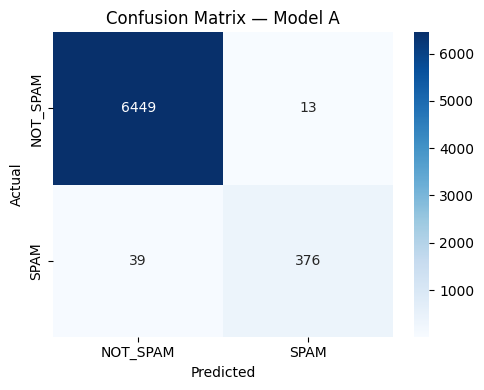


  B — Metadata-Only MLP
              precision    recall  f1-score   support

    NOT_SPAM     0.9886    0.9947    0.9917      6462
        SPAM     0.9093    0.8217    0.8633       415

    accuracy                         0.9843      6877
   macro avg     0.9490    0.9082    0.9275      6877
weighted avg     0.9838    0.9843    0.9839      6877



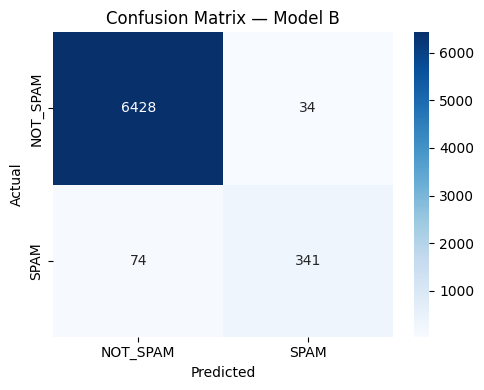


  C — Concatenation Fusion
              precision    recall  f1-score   support

    NOT_SPAM     0.9945    0.9988    0.9966      6462
        SPAM     0.9793    0.9133    0.9451       415

    accuracy                         0.9936      6877
   macro avg     0.9869    0.9560    0.9709      6877
weighted avg     0.9935    0.9936    0.9935      6877



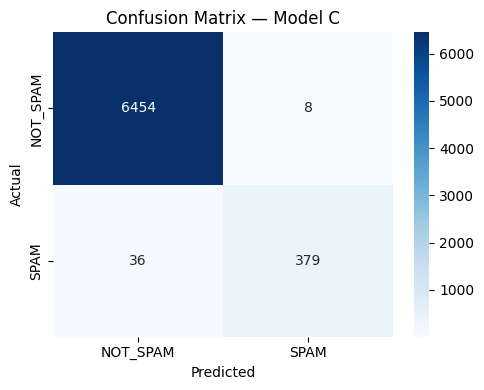


  D — Modality-Aware Gated Fusion
              precision    recall  f1-score   support

    NOT_SPAM     0.9955    0.9964    0.9960      6462
        SPAM     0.9438    0.9301    0.9369       415

    accuracy                         0.9924      6877
   macro avg     0.9696    0.9633    0.9664      6877
weighted avg     0.9924    0.9924    0.9924      6877



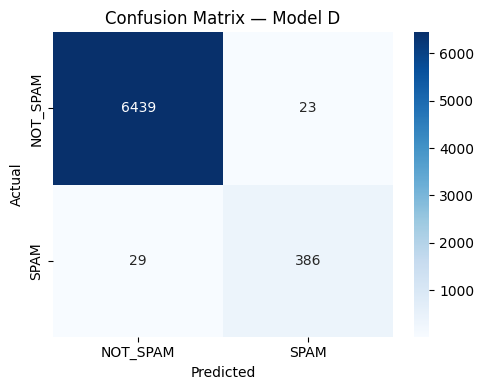

In [11]:
label_names = ["NOT_SPAM", "SPAM"]


def full_eval(res):
    name   = res["name"]
    preds  = res["test_preds"]
    labels = res["test_labels"]

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(labels, preds,
                                 target_names=label_names, digits=4))

    cm  = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — Model {name[0]}")
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS["output_dir"],
                             f"cm_model_{name[0]}.png"), dpi=150)
    plt.show()

    rd = classification_report(labels, preds, target_names=label_names,
                                digits=4, output_dict=True)
    return {
        "Model"         : f"Model {name[0]}",
        "Accuracy"      : rd["accuracy"],
        "SPAM Precision": rd["SPAM"]["precision"],
        "SPAM Recall"   : rd["SPAM"]["recall"],
        "SPAM F1"       : rd["SPAM"]["f1-score"],
        "NOT_SPAM F1"   : rd["NOT_SPAM"]["f1-score"],
        "Macro F1"      : rd["macro avg"]["f1-score"],
        "Weighted F1"   : rd["weighted avg"]["f1-score"],
    }


eval_a = full_eval(results_a)
eval_b = full_eval(results_b)
eval_c = full_eval(results_c)
eval_d = full_eval(results_d)

## Cell 15 — Summary Table 4 Model

In [12]:
summary_df = pd.DataFrame([eval_a, eval_b, eval_c, eval_d])
summary_df["Model"] = [
    "A: Text-Only (IndoRoBERTa)",
    "B: MLP-Only (Metadata)",
    "C: Concatenation Fusion",
    "D: Modality-Aware Gated Fusion",
]

display_df = summary_df.copy()
for col in display_df.columns[1:]:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.2f}%")

print("\n" + "="*75)
print("  FINAL TEST RESULTS — 4 MODEL COMPARISON")
print("="*75)
print(display_df.to_string(index=False))

# Highlight winner per metric
print("\nWinner per metric:")
for col in ["SPAM F1", "Macro F1", "SPAM Recall", "Accuracy"]:
    idx = summary_df[col].idxmax()
    print(f"  {col:<18}: {summary_df.loc[idx,'Model']} "
          f"({summary_df.loc[idx,col]*100:.2f}%)")

save_path = os.path.join(PATHS["output_dir"], "summary_results.csv")
summary_df.to_csv(save_path, index=False)
print(f"\nSaved → {save_path}")


  FINAL TEST RESULTS — 4 MODEL COMPARISON
                         Model Accuracy SPAM Precision SPAM Recall SPAM F1 NOT_SPAM F1 Macro F1 Weighted F1
    A: Text-Only (IndoRoBERTa)   99.24%         96.66%      90.60%  93.53%      99.60%   96.57%      99.23%
        B: MLP-Only (Metadata)   98.43%         90.93%      82.17%  86.33%      99.17%   92.75%      98.39%
       C: Concatenation Fusion   99.36%         97.93%      91.33%  94.51%      99.66%   97.09%      99.35%
D: Modality-Aware Gated Fusion   99.24%         94.38%      93.01%  93.69%      99.60%   96.64%      99.24%

Winner per metric:
  SPAM F1           : C: Concatenation Fusion (94.51%)
  Macro F1          : C: Concatenation Fusion (97.09%)
  SPAM Recall       : D: Modality-Aware Gated Fusion (93.01%)
  Accuracy          : C: Concatenation Fusion (99.36%)

Saved → final_results\summary_results.csv


## Cell 16 — Training History

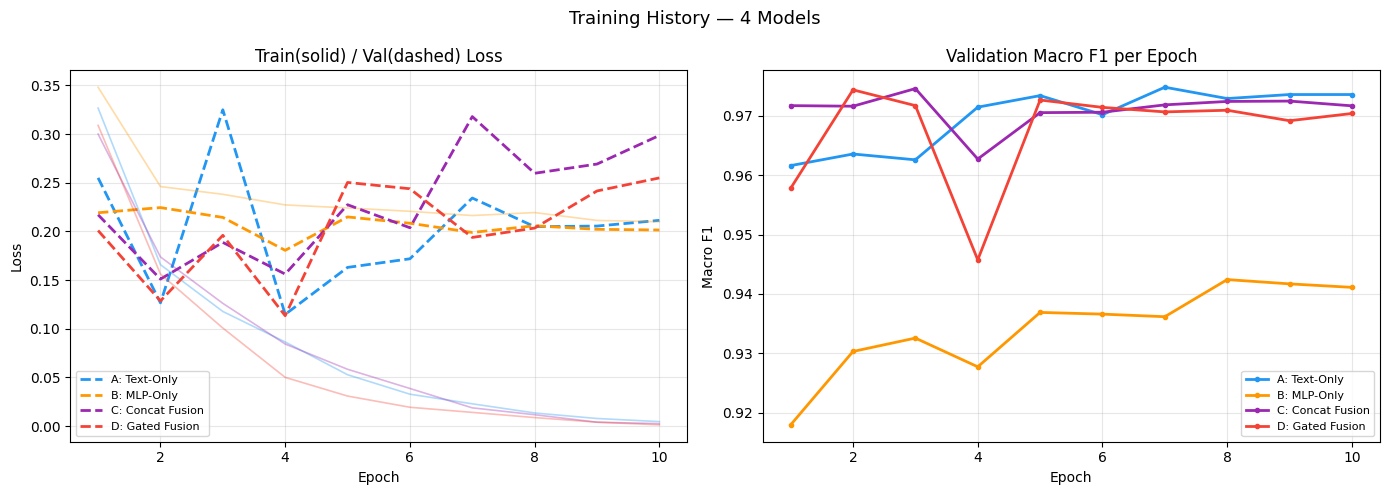

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = [
    (results_a, "A: Text-Only",     "#2196F3"),
    (results_b, "B: MLP-Only",      "#FF9800"),
    (results_c, "C: Concat Fusion", "#9C27B0"),
    (results_d, "D: Gated Fusion",  "#F44336"),
]

for res, label, color in configs:
    ep = range(1, len(res["history"]["val_f1"]) + 1)
    axes[0].plot(ep, res["history"]["train_loss"], "-",
                 color=color, alpha=0.35, lw=1.2)
    axes[0].plot(ep, res["history"]["val_loss"], "--",
                 color=color, lw=2, label=label)
    axes[1].plot(ep, res["history"]["val_f1"],
                 color=color, lw=2, marker="o", ms=3, label=label)

axes[0].set(xlabel="Epoch", ylabel="Loss",
            title="Train(solid) / Val(dashed) Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set(xlabel="Epoch", ylabel="Macro F1",
            title="Validation Macro F1 per Epoch")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle("Training History — 4 Models", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PATHS["output_dir"], "training_history.png"), dpi=150)
plt.show()

## Cell 17 — Fusion Weight Analysis (α) — Model D
Section 3.7.2 — α mendekati 1.0 = model mengandalkan teks,  α mendekati 0.0 = metadata

In [14]:
def extract_alpha(model, loader):
    model.eval()
    alphas, labs = [], []
    _, _, _, test_labels_loader = [], [], [], []

    # Rebuild test loader dengan batch_size kecil untuk extract alpha
    test_loader_alpha = DataLoader(
        SpamDataset(df_test, use_text=True, use_numeric=True),
        batch_size=32, shuffle=False, num_workers=0,
    )

    with torch.no_grad():
        for batch in tqdm(test_loader_alpha, desc="Extracting α", leave=False):
            iid = batch["input_ids"].to(device)
            msk = batch["attention_mask"].to(device)
            num = batch["numeric"].to(device)
            α   = model.get_alpha(iid, msk, num)  # (B,) scalar
            alphas.extend(α.cpu().numpy())
            labs.extend(batch["labels"].numpy())

    return np.array(alphas), np.array(labs)


alphas, alpha_labels = extract_alpha(results_d["model"], None)

spam_α     = alphas[alpha_labels == 1]
not_spam_α = alphas[alpha_labels == 0]

print("α Statistics (scalar per sample ∈ [0,1]):")
print(f"  SPAM     — mean={spam_α.mean():.4f} | std={spam_α.std():.4f} | median={np.median(spam_α):.4f}")
print(f"  NOT_SPAM — mean={not_spam_α.mean():.4f} | std={not_spam_α.std():.4f} | median={np.median(not_spam_α):.4f}")
print()
if spam_α.mean() > 0.5:
    print("Interpretasi: Model D lebih mengandalkan TEKS saat mendeteksi SPAM")
else:
    print("Interpretasi: Model D lebih mengandalkan METADATA saat mendeteksi SPAM")

Extracting α:   0%|          | 0/215 [00:00<?, ?it/s]

α Statistics (scalar per sample ∈ [0,1]):
  SPAM     — mean=0.9838 | std=0.0130 | median=0.9862
  NOT_SPAM — mean=0.9340 | std=0.1043 | median=0.9560

Interpretasi: Model D lebih mengandalkan TEKS saat mendeteksi SPAM


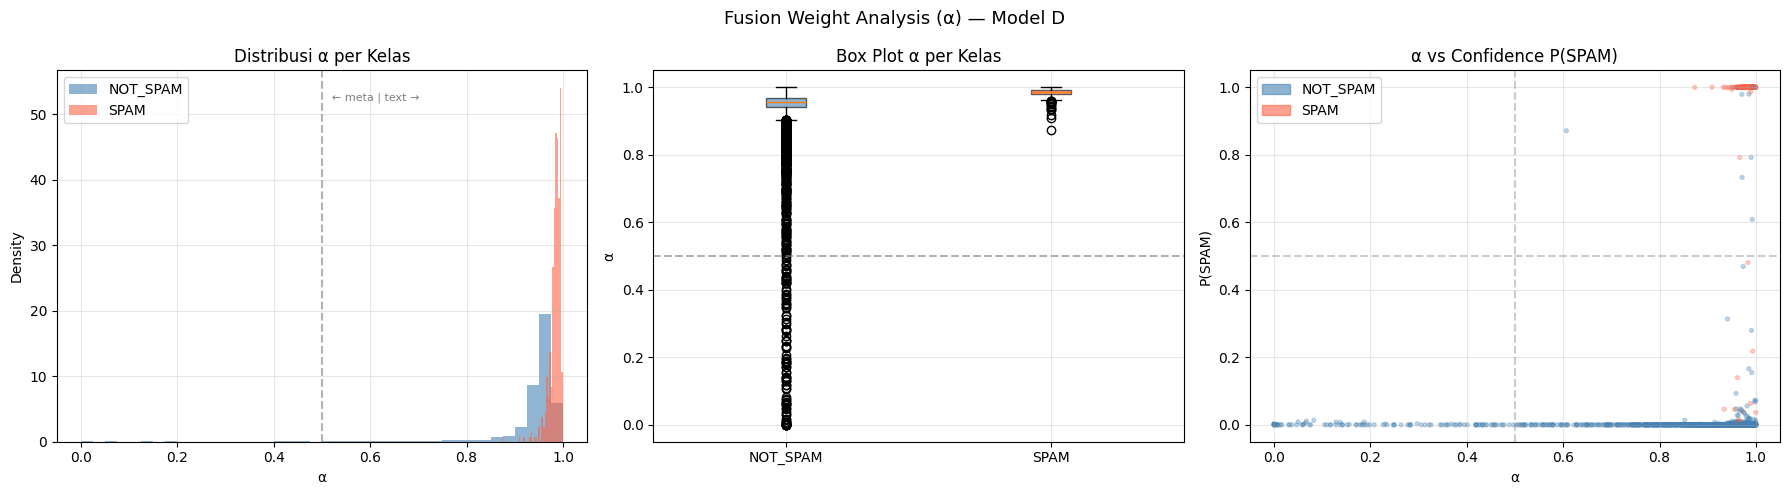

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram
axes[0].hist(not_spam_α, bins=40, alpha=0.6, label="NOT_SPAM",
             color="steelblue", density=True)
axes[0].hist(spam_α,     bins=40, alpha=0.6, label="SPAM",
             color="tomato", density=True)
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.6)
axes[0].set(xlabel="α", ylabel="Density", title="Distribusi α per Kelas")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].text(0.52, axes[0].get_ylim()[1]*0.92,
             "← meta | text →", fontsize=8, color="gray")

# 2. Boxplot
bp = axes[1].boxplot([not_spam_α, spam_α],
                      labels=["NOT_SPAM","SPAM"], patch_artist=True)
for patch, color in zip(bp["boxes"], ["steelblue","tomato"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.6)
axes[1].set(ylabel="α", title="Box Plot α per Kelas")
axes[1].grid(True, alpha=0.3)

# 3. α vs P(SPAM) scatter
test_loader_scatter = DataLoader(
    SpamDataset(df_test, use_text=True, use_numeric=True),
    batch_size=64, shuffle=False, num_workers=0,
)
probs = []
results_d["model"].eval()
with torch.no_grad():
    for batch in test_loader_scatter:
        logits = results_d["model"](
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            numeric=batch["numeric"].to(device),
        )
        probs.extend(torch.softmax(logits.float(), -1)[:, 1].cpu().numpy())
probs = np.array(probs)

colors_sc = ["steelblue" if l == 0 else "tomato" for l in alpha_labels]
axes[2].scatter(alphas, probs, c=colors_sc, alpha=0.3, s=8)
axes[2].axhline(0.5, color="gray", linestyle="--", alpha=0.4)
axes[2].axvline(0.5, color="gray", linestyle="--", alpha=0.4)
axes[2].set(xlabel="α", ylabel="P(SPAM)", title="α vs Confidence P(SPAM)")
axes[2].legend(handles=[
    mpatches.Patch(color="steelblue", alpha=0.6, label="NOT_SPAM"),
    mpatches.Patch(color="tomato",    alpha=0.6, label="SPAM"),
]); axes[2].grid(True, alpha=0.3)

plt.suptitle("Fusion Weight Analysis (α) — Model D", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PATHS["output_dir"], "alpha_analysis.png"), dpi=150)
plt.show()

## Cell 18 — Significance Test (Wilcoxon)
Section 1.3 — H₁: Model D berbeda signifikan dari baseline, α = 0.05

In [16]:
def bootstrap_f1(preds, labels, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(labels), len(labels))
        scores.append(f1_score(labels[idx], preds[idx],
                               average="macro", zero_division=0))
    return np.array(scores)


print("Bootstrap F1 (1000 samples)...")
bs = {
    "A": bootstrap_f1(results_a["test_preds"], results_a["test_labels"]),
    "B": bootstrap_f1(results_b["test_preds"], results_b["test_labels"]),
    "C": bootstrap_f1(results_c["test_preds"], results_c["test_labels"]),
    "D": bootstrap_f1(results_d["test_preds"], results_d["test_labels"]),
}

print("\nBootstrap Macro F1 (mean ± std, 95% CI):")
labels_map = {"A":"Text-Only","B":"MLP-Only","C":"Concat Fusion","D":"Gated Fusion"}
for k, b in bs.items():
    lo, hi = np.percentile(b, [2.5, 97.5])
    print(f"  Model {k} ({labels_map[k]:<16}): "
          f"{b.mean():.4f} ± {b.std():.4f}  CI=[{lo:.4f}, {hi:.4f}]")

print()
print("Wilcoxon Signed-Rank Test: Model D vs Baselines (α = 0.05)")
print("-" * 58)
print(f"  {'Perbandingan':<28} {'p-value':>8}  {'stat':>8}  Keputusan")
print("-" * 58)

for key, label in [("A","D vs A (Text-Only)"),
                    ("B","D vs B (MLP-Only)"),
                    ("C","D vs C (Concat Fusion)")]:
    stat, p = scipy_stats.wilcoxon(bs["D"], bs[key], alternative="greater")
    decision = "Tolak H₀ ✅" if p < 0.05 else "Gagal tolak H₀ ❌"
    print(f"  {label:<28} {p:>8.4f}  {stat:>8.1f}  {decision}")

print()
print("Hipotesis:")
print("  H₀: Tidak ada perbedaan signifikan (p ≥ 0.05)")
print("  H₁: Model D berbeda signifikan (p < 0.05)")

Bootstrap F1 (1000 samples)...

Bootstrap Macro F1 (mean ± std, 95% CI):
  Model A (Text-Only       ): 0.9659 ± 0.0047  CI=[0.9566, 0.9746]
  Model B (MLP-Only        ): 0.9277 ± 0.0066  CI=[0.9149, 0.9398]
  Model C (Concat Fusion   ): 0.9710 ± 0.0044  CI=[0.9623, 0.9792]
  Model D (Gated Fusion    ): 0.9667 ± 0.0047  CI=[0.9567, 0.9752]

Wilcoxon Signed-Rank Test: Model D vs Baselines (α = 0.05)
----------------------------------------------------------
  Perbandingan                  p-value      stat  Keputusan
----------------------------------------------------------
  D vs A (Text-Only)             0.0000  306683.0  Tolak H₀ ✅
  D vs B (MLP-Only)              0.0000  500500.0  Tolak H₀ ✅
  D vs C (Concat Fusion)         1.0000   26246.0  Gagal tolak H₀ ❌

Hipotesis:
  H₀: Tidak ada perbedaan signifikan (p ≥ 0.05)
  H₁: Model D berbeda signifikan (p < 0.05)


---
## ✅ Output yang Dihasilkan

```
final_results/
├── model_A_best.pt          ← saved model weights
├── model_B_best.pt
├── model_C_best.pt
├── model_D_best.pt
├── cm_model_A.png           ← confusion matrix
├── cm_model_B.png
├── cm_model_C.png
├── cm_model_D.png
├── training_history.png     ← loss + F1 curves
├── alpha_analysis.png       ← distribusi α Model D
└── summary_results.csv      ← tabel perbandingan 4 model
```

Semua angka di tabel di atas → langsung masuk ke **Bab 4 skripsi**.
